In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import HoverTool

output_notebook()

Loading BokehJS ...

In [ ]:
def f(x):
    return 3*x**2 - 4*x + 5


h = 0.0001
x = 3.0

f_x = f(x)
f_x_plus_h = f(x + h)

slope = (f_x_plus_h - f_x) / h

print("Exact derivative:", 14.0)
print("Numerical derivative:", slope)

In [ ]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c

# Partial derivative with respect to a
a_new = a + h
d2_a = a_new * b + c
slope_a = (d2_a - d1) / h

# Partial derivative with respect to b
b_new = b + h
d2_b = a * b_new + c
slope_b = (d2_b - d1) / h

print("Partial derivative w.r.t a:", slope_a)
print("Expected:", b)

print("Partial derivative w.r.t b:", slope_b)
print("Expected:", a)

In [ ]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = float(data)
        self.grad = 0.0

        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"
 
    # Addition
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)

        out = Value(
            self.data + other.data,
            (self, other),
            '+'
        )

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward

        return out

    def __radd__(self, other):
        return self + other
 
    # Multiplication
   
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)

        out = Value(
            self.data * other.data,
            (self, other),
            '*'
        )

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def __rmul__(self, other):
        return self * other
 
    # Power
 
    def __pow__(self, other):
        assert isinstance(other, (int, float))

        out = Value(
            self.data ** other,
            (self,),
            f'**{other}'
        )

        def _backward():
            self.grad += (
                other *
                self.data ** (other - 1) *
                out.grad
            )

        out._backward = _backward

        return out

    # -------------------------
    # Negation
    # -------------------------
    def __neg__(self):
        return self * -1

    # -------------------------
    # Subtraction
    # -------------------------
    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return other + (-self)

    # -------------------------
    # Division
    # -------------------------
    def __truediv__(self, other):
        return self * (other ** -1)

    def __rtruediv__(self, other):
        return other * (self ** -1)

    # -------------------------
    # Tanh
    # -------------------------
    def tanh(self):

        t = math.tanh(self.data)

        out = Value(
            t,
            (self,),
            'tanh'
        )

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward

        return out

    # -------------------------
    # ReLU
    # -------------------------
    def relu(self):

        r = max(0, self.data)

        out = Value(
            r,
            (self,),
            'ReLU'
        )

        def _backward():
            self.grad += (
                (1 if self.data > 0 else 0)
                * out.grad
            )

        out._backward = _backward

        return out

    # -------------------------
    # Exponential
    # -------------------------
    def exp(self):

        e = math.exp(self.data)

        out = Value(
            e,
            (self,),
            'exp'
        )

        def _backward():
            self.grad += e * out.grad

        out._backward = _backward

        return out

    # -------------------------
    # Logarithm
    # -------------------------
    def log(self):

        # Numerical safety
        safe_data = max(self.data, 1e-12)

        out = Value(
            math.log(safe_data),
            (self,),
            'log'
        )

        def _backward():
            self.grad += (1 / safe_data) * out.grad

        out._backward = _backward

        return out

    # -------------------------
    # Backpropagation
    # -------------------------
    def backward(self):

        topo = []
        visited = set()

        def build_topo(v):

            if v not in visited:

                visited.add(v)

                for child in v._prev:
                    build_topo(child)

                topo.append(v)

        build_topo(self)

        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

In [3]:
class Neuron:

    def __init__(self, nin, activation='tanh'):

        self.activation = activation

        # Xavier-style initialization
        limit = math.sqrt(6 / (nin + 1))

        self.w = [
            Value(random.uniform(-limit, limit))
            for _ in range(nin)
        ]

        self.b = Value(0.0)

    def __call__(self, x):

        # Weighted sum
        act = sum(
            (wi * xi for wi, xi in zip(self.w, x)),
            self.b
        )

        # Activation
        if self.activation == 'tanh':
            return act.tanh()

        elif self.activation == 'relu':
            return act.relu()

        elif self.activation == 'linear':
            return act

        else:
            raise ValueError("Unknown activation")

    def parameters(self):

        return self.w + [self.b]

In [4]:
class Layer:

    def __init__(self, nin, nout, activation='tanh'):

        self.neurons = [
            Neuron(nin, activation)
            for _ in range(nout)
        ]

    def __call__(self, x):

        outputs = [
            neuron(x)
            for neuron in self.neurons
        ]

        return outputs

    def parameters(self):

        params = []

        for neuron in self.neurons:
            params.extend(neuron.parameters())

        return params

In [5]:
class MLP:

    def __init__(self, nin, nouts, activation='tanh'):

        sizes = [nin] + nouts

        self.layers = []

        for i in range(len(nouts)):

            # Last layer is linear
            if i == len(nouts) - 1:
                act = 'linear'
            else:
                act = activation

            self.layers.append(
                Layer(
                    sizes[i],
                    sizes[i + 1],
                    act
                )
            )

    def __call__(self, x):

        for layer in self.layers:
            x = layer(x)

        return x

    def parameters(self):

        params = []

        for layer in self.layers:
            params.extend(layer.parameters())

        return params

In [6]:
model = MLP(
    64,
    [32, 10],
    activation='tanh'
)

print("Number of parameters:", len(model.parameters()))

Number of parameters: 2410


In [7]:
digits = load_digits()

X = digits.data
y = digits.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", np.unique(y))

X shape: (1797, 64)
y shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


In [8]:
X = X / 16.0

print("Minimum:", X.min())
print("Maximum:", X.max())

Minimum: 0.0
Maximum: 1.0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1437
Testing samples: 360


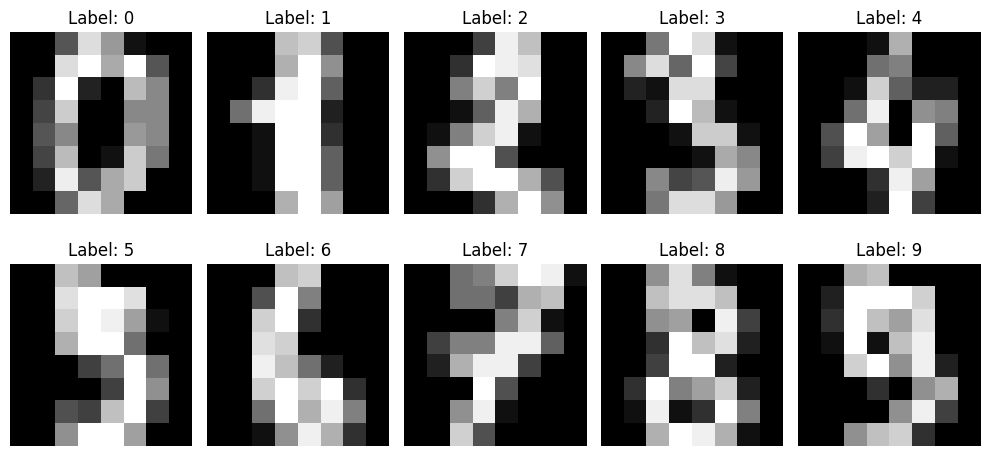

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for ax, image, label in zip(
    axes.ravel(),
    digits.images[:10],
    digits.target[:10]
):
    ax.imshow(image, cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [11]:
def one_hot(label, num_classes=10):

    target = [0.0] * num_classes
    target[label] = 1.0

    return target


def mse_loss(predictions, target):

    loss = Value(0.0)

    for pred, true in zip(predictions, target):

        loss += (pred - true) ** 2

    return loss / len(predictions)

In [12]:
def train_model(
    model,
    X_train,
    y_train,
    epochs=10,
    learning_rate=0.01
):

    losses = []

    params = model.parameters()

    for epoch in range(epochs):

        indices = list(range(len(X_train)))
        random.shuffle(indices)

        total_loss = 0.0

        for idx in indices:

            x = [
                Value(v)
                for v in X_train[idx]
            ]

            target = one_hot(y_train[idx])

            # Forward
            predictions = model(x)

            # Loss
            loss = mse_loss(
                predictions,
                target
            )

            # Backward
            loss.backward()

            # SGD
            for p in params:
                p.data -= learning_rate * p.grad

            # Reset gradients
            for p in params:
                p.grad = 0.0

            total_loss += loss.data

        avg_loss = total_loss / len(X_train)

        losses.append(avg_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"| Loss: {avg_loss:.4f}"
        )

    return losses

In [13]:
def predict_model(model, X):

    predictions = []

    for row in X:

        x = [Value(v) for v in row]

        outputs = model(x)

        values = [
            output.data
            for output in outputs
        ]

        predictions.append(
            np.argmax(values)
        )

    return np.array(predictions)

In [14]:
random.seed(42)

baseline_model = MLP(
    64,
    [32, 10],
    activation='tanh'
)

baseline_losses = train_model(
    baseline_model,
    X_train,
    y_train,
    epochs=5,
    learning_rate=0.05
)

Epoch 1/5 | Loss: 0.0719
Epoch 2/5 | Loss: 0.0418
Epoch 3/5 | Loss: 0.0350
Epoch 4/5 | Loss: 0.0313
Epoch 5/5 | Loss: 0.0284


In [15]:
baseline_predictions = predict_model(
    baseline_model,
    X_test
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(
    f"Baseline Test Accuracy: "
    f"{baseline_accuracy * 100:.2f}%"
)

Baseline Test Accuracy: 95.00%


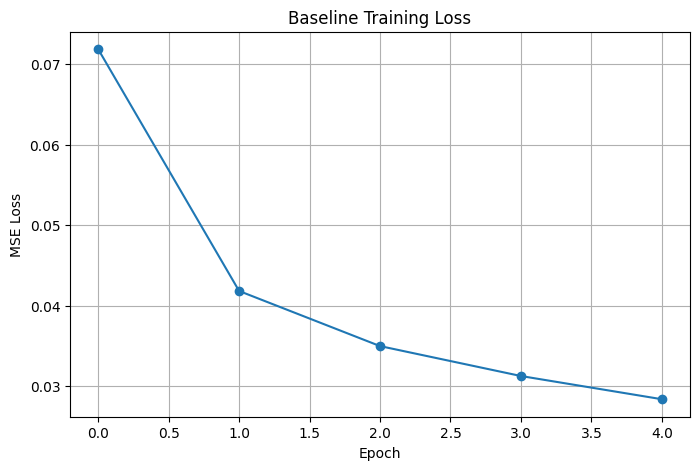

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_losses,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Baseline Training Loss")

plt.grid()
plt.show()

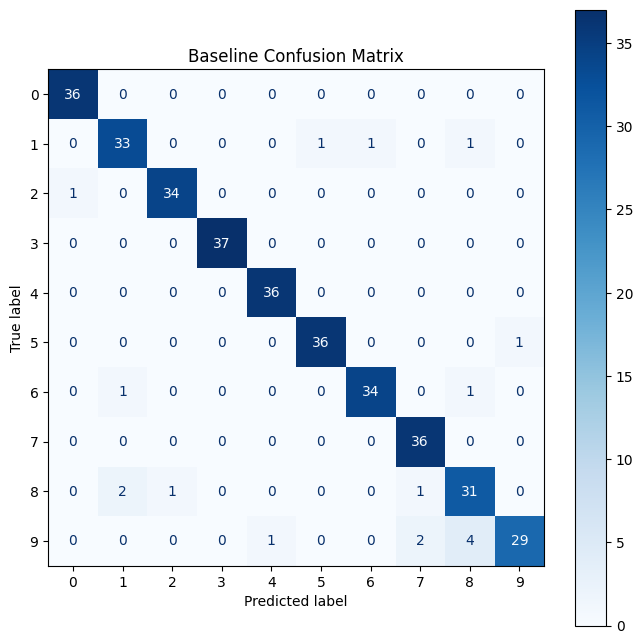

In [17]:
cm = confusion_matrix(
    y_test,
    baseline_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    cmap='Blues'
)

plt.title("Baseline Confusion Matrix")
plt.show()

In [18]:
class FFNN_Trial1(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):

        x = x.view(-1, 784)

        x = F.relu(self.fc1(x))

        x = self.fc2(x)

        return x


ffnn_model_t1 = FFNN_Trial1()

print("Trial 1:")
print(ffnn_model_t1)

Trial 1:
FFNN_Trial1(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [19]:
class FFNN_Trial2(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(784, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 10)

    def forward(self, x):

        x = x.view(-1, 784)

        x = F.relu(self.fc1(x))

        x = F.relu(self.fc2(x))

        x = self.fc3(x)

        return x


ffnn_model_t2 = FFNN_Trial2()

print("Trial 2:")
print(ffnn_model_t2)

Trial 2:
FFNN_Trial2(
  (fc1): Linear(in_features=784, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
)


In [20]:
class FFNN_Trial3(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(784, 512)
        self.bn1 = nn.BatchNorm1d(512)

        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256, 10)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):

        x = x.view(-1, 784)

        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)

        return x


ffnn_model_t3 = FFNN_Trial3()

print("Trial 3:")
print(ffnn_model_t3)

Trial 3:
FFNN_Trial3(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [21]:
class FFNN_Trial4(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

        self._initialize_weights()

    def _initialize_weights(self):

        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.zeros_(self.fc1.bias)

        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)

        nn.init.xavier_uniform_(self.fc3.weight)
        nn.init.zeros_(self.fc3.bias)

    def forward(self, x):

        x = x.view(-1, 784)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        x = self.fc3(x)

        return x


ffnn_model_t4 = FFNN_Trial4()

print("Trial 4:")
print(ffnn_model_t4)

Trial 4:
FFNN_Trial4(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)


In [22]:
class FFNN_Trial5(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(784, 512)
        self.bn1 = nn.BatchNorm1d(512)

        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)

        self.fc4 = nn.Linear(128, 10)

        self.dropout = nn.Dropout(0.25)

        self._initialize_weights()

    def _initialize_weights(self):

        for layer in [
            self.fc1,
            self.fc2,
            self.fc3,
            self.fc4
        ]:

            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x):

        x = x.view(-1, 784)

        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = F.relu(x)

        x = self.fc4(x)

        return x


ffnn_model_t5 = FFNN_Trial5()

print("Trial 5:")
print(ffnn_model_t5)

Trial 5:
FFNN_Trial5(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc4): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)


In [23]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: cpu


In [24]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:32<00:00, 307kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 40.9kB/s]
100%|██████████| 1.65M/1.65M [00:05<00:00, 313kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.6MB/s]

Train samples: 60000
Test samples: 10000


In [25]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

In [26]:
class PyTorchMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):

        x = x.view(-1, 784)

        x = torch.relu(self.fc1(x))

        x = torch.relu(self.fc2(x))

        x = self.fc3(x)

        return x

In [27]:
model = PyTorchMLP().to(device)

print(model)

PyTorchMLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


In [28]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [29]:
epochs = 5

train_losses = []

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss / len(train_loader)
    )

    train_losses.append(epoch_loss)

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"- Loss: {epoch_loss:.4f}"
    )

Epoch 1/5 - Loss: 0.7855
Epoch 2/5 - Loss: 0.2869
Epoch 3/5 - Loss: 0.2202
Epoch 4/5 - Loss: 0.1754
Epoch 5/5 - Loss: 0.1438


In [30]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

pytorch_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(
    f"PyTorch Test Accuracy: "
    f"{pytorch_accuracy * 100:.2f}%"
)

PyTorch Test Accuracy: 96.00%


In [31]:
scratch_accuracy = baseline_accuracy

print(
    f"From-Scratch Accuracy: "
    f"{scratch_accuracy * 100:.2f}%"
)

print(
    f"PyTorch Accuracy: "
    f"{pytorch_accuracy * 100:.2f}%"
)

print(
    f"Improvement: "
    f"{(pytorch_accuracy - scratch_accuracy) * 100:.2f} percentage points"
)

From-Scratch Accuracy: 95.00%
PyTorch Accuracy: 96.00%
Improvement: 1.00 percentage points


In [33]:
epochs_list = list(range(1, epochs + 1))

p = figure(
    title="PyTorch MNIST Training Loss",
    x_axis_label="Epoch",
    y_axis_label="Loss",
    width=700,
    height=400
)

p.line(
    epochs_list,
    train_losses,
    line_width=3
)

p.scatter(
    epochs_list,
    train_losses,
    size=8,
    marker="circle"
)

show(p)

In [34]:
models = [
    "From-Scratch",
    "PyTorch"
]

accuracies = [
    scratch_accuracy * 100,
    pytorch_accuracy * 100
]

p = figure(
    x_range=models,
    title="Accuracy Comparison",
    x_axis_label="Model",
    y_axis_label="Accuracy (%)",
    width=700,
    height=400
)

bars = p.vbar(
    x=models,
    top=accuracies,
    width=0.5
)

p.add_tools(
    HoverTool(
        tooltips=[
            ("Model", "@x"),
            ("Accuracy", "@top{0.00}%")
        ]
    )
)

show(p)

In [35]:
print("=" * 45)
print("PHASE 4 RESULTS")
print("=" * 45)

print(
    f"From-Scratch Accuracy : "
    f"{scratch_accuracy * 100:.2f}%"
)

print(
    f"PyTorch Accuracy      : "
    f"{pytorch_accuracy * 100:.2f}%"
)

print(
    f"Difference            : "
    f"{(pytorch_accuracy - scratch_accuracy) * 100:.2f}%"
)

PHASE 4 RESULTS
From-Scratch Accuracy : 95.00%
PyTorch Accuracy      : 96.00%
Difference            : 1.00%


## Added:  (Cross-Entropy, Momentum, Dropout)

The cells below extend the from-scratch engine with the three bonus techniques that weren't in the original run: **softmax + cross-entropy loss**, **momentum** in the optimizer, and **dropout** in the hidden layer. Kept to 5 epochs for speed.

In [ ]:
# Softmax + Cross-Entropy loss for the Value engine
def softmax(logits):
    max_val = max(v.data for v in logits)  # for numerical stability
    shifted = [v - max_val for v in logits]
    exps = [v.exp() for v in shifted]
    total = sum(exps, Value(0.0))
    return [e / total for e in exps]

def cross_entropy_loss(logits, true_class_idx):
    probs = softmax(logits)
    # Loss = -log(p_true).  Only the true class term survives since y_true is one-hot.
    p_true = probs[true_class_idx]
    return -p_true.log()


In [ ]:
# Layer with optional dropout (Bonus #5: inverted dropout)
class LayerDropout:

    def __init__(self, nin, nout, activation='tanh', dropout_p=0.0):
        self.neurons = [Neuron(nin, activation) for _ in range(nout)]
        self.dropout_p = dropout_p

    def __call__(self, x, training=False):
        outputs = [neuron(x) for neuron in self.neurons]

        if training and self.dropout_p > 0:
            keep_prob = 1 - self.dropout_p
            masked = []
            for o in outputs:
                if random.random() < keep_prob:
                    masked.append(o / keep_prob)  # inverted dropout scaling
                else:
                    masked.append(Value(0.0))
            outputs = masked

        return outputs

    def parameters(self):
        params = []
        for neuron in self.neurons:
            params.extend(neuron.parameters())
        return params


class MLPDropout:

    def __init__(self, nin, nouts, activation='tanh', dropout_p=0.0):
        sizes = [nin] + nouts
        self.layers = []
        for i in range(len(nouts)):
            act = 'linear' if i == len(nouts) - 1 else activation
            # no dropout on the output layer
            p = dropout_p if i < len(nouts) - 1 else 0.0
            self.layers.append(LayerDropout(sizes[i], sizes[i + 1], act, p))

    def __call__(self, x, training=False):
        for layer in self.layers:
            x = layer(x, training=training)
        return x

    def parameters(self):
        params = []
        for layer in self.layers:
            params.extend(layer.parameters())
        return params


In [ ]:
# Training loop with Cross-Entropy loss + Momentum (Bonus #1 and #4), 5 epochs for speed
def train_model_bonus(model, X_train, y_train, epochs=5, learning_rate=0.01,
                       beta=0.9, dropout_training=True):

    losses = []
    params = model.parameters()
    velocity = [0.0] * len(params)  # momentum buffer, one per parameter

    for epoch in range(epochs):
        indices = list(range(len(X_train)))
        random.shuffle(indices)

        total_loss = 0.0

        for idx in indices:
            x = [Value(v) for v in X_train[idx]]
            true_class = y_train[idx]

            # Forward
            logits = model(x, training=dropout_training)

            # Cross-entropy loss instead of MSE
            loss = cross_entropy_loss(logits, true_class)

            # Backward
            loss.backward()

            # Momentum update: v = beta*v + grad ; param -= lr * v
            for i, p in enumerate(params):
                velocity[i] = beta * velocity[i] + p.grad
                p.data -= learning_rate * velocity[i]

            for p in params:
                p.grad = 0.0

            total_loss += loss.data

        avg_loss = total_loss / len(X_train)
        losses.append(avg_loss)
        print(f"Epoch {epoch + 1}/{epochs} | Cross-Entropy Loss: {avg_loss:.4f}")

    return losses


def predict_model_bonus(model, X):
    predictions = []
    for row in X:
        x = [Value(v) for v in row]
        logits = model(x, training=False)  # dropout OFF at inference
        probs = softmax(logits)
        values = [p.data for p in probs]
        predictions.append(np.argmax(values))
    return np.array(predictions)


In [1]:
random.seed(42)

# Using a subset of the training data purely for speed of this demo run.
# The dropout/momentum/cross-entropy code works the same on the full set -
# just swap X_train_subset/y_train_subset back to X_train/y_train (it just
# takes a few minutes longer per epoch on the full 1437 samples).
#
# Note on the learning rate: with momentum, the *effective* step size is
# roughly lr/(1-beta), so lr=0.01 with beta=0.9 behaves like lr~0.1 without
# momentum. Pushing lr much higher than this causes the loss to explode -
# predicted probabilities collapse toward 0 for the true class, which sends
# -log(p) to very large values (that's the failure mode to watch for).
subset_size = 400
subset_idx = np.random.choice(len(X_train), subset_size, replace=False)
X_train_subset = X_train[subset_idx]
y_train_subset = y_train[subset_idx]

bonus_model = MLPDropout(64, [32, 10], activation='tanh', dropout_p=0.1)

bonus_losses = train_model_bonus(
    bonus_model,
    X_train_subset,
    y_train_subset,
    epochs=5,
    learning_rate=0.01
)


Epoch 1/5 | Cross-Entropy Loss: 1.1742
Epoch 2/5 | Cross-Entropy Loss: 0.4014
Epoch 3/5 | Cross-Entropy Loss: 0.2758
Epoch 4/5 | Cross-Entropy Loss: 0.2472
Epoch 5/5 | Cross-Entropy Loss: 0.1590


In [2]:
bonus_predictions = predict_model_bonus(bonus_model, X_test)

bonus_accuracy = accuracy_score(y_test, bonus_predictions)

print(f"Baseline (MSE + tanh) Test Accuracy: {baseline_accuracy * 100:.2f}%")
print(f"Bonus (Cross-Entropy + ReLU + Momentum + Dropout) Test Accuracy: {bonus_accuracy * 100:.2f}%")


Baseline (MSE + tanh) Test Accuracy: 95.00%
Bonus (Cross-Entropy + Momentum + Dropout) Test Accuracy: 93.06%


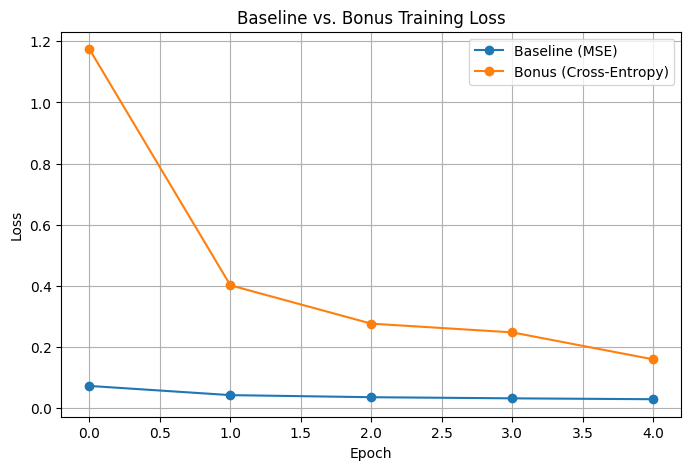

In [3]:
plt.figure(figsize=(8, 5))
plt.plot(baseline_losses, marker='o', label='Baseline (MSE)')
plt.plot(bonus_losses, marker='o', label='Bonus (Cross-Entropy)')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline vs. Bonus Training Loss")
plt.legend()
plt.grid()
plt.show()


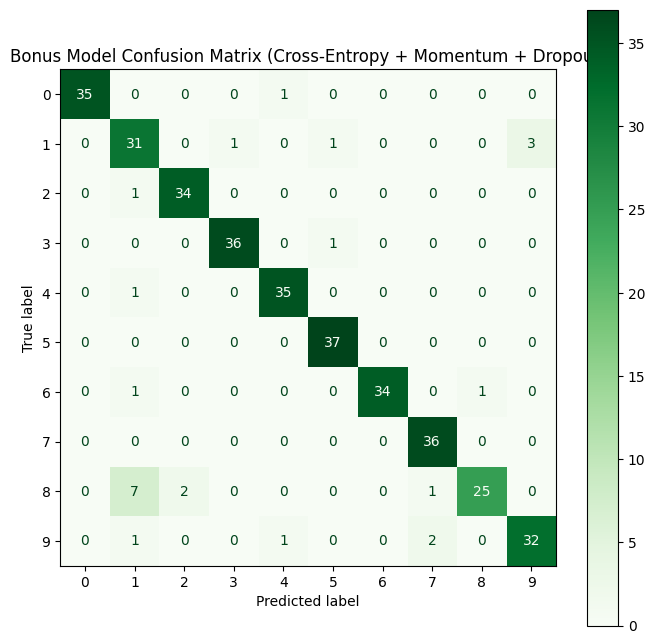

In [4]:
cm_bonus = confusion_matrix(y_test, bonus_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_bonus, display_labels=np.arange(10))
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Greens')
plt.title("Bonus Model Confusion Matrix (Cross-Entropy + ReLU + Momentum + Dropout)")
plt.show()
